In [234]:
from sklearn.datasets import load_digits

digits = load_digits()

#print(digits.DESCR)
print(digits.data[0])
print(digits.target)

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]


In [235]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)

model.fit(digits.data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


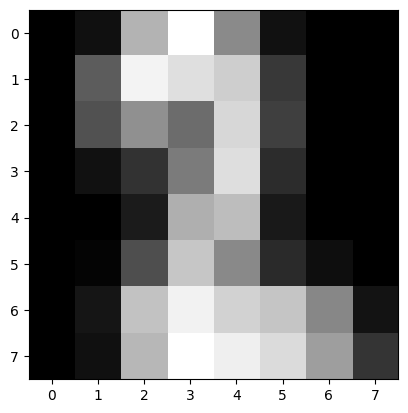

In [236]:
import matplotlib.pyplot as plt

plt.imshow(model.cluster_centers_[0].reshape(8, 8), cmap='gray')
plt.show()
plt.close()

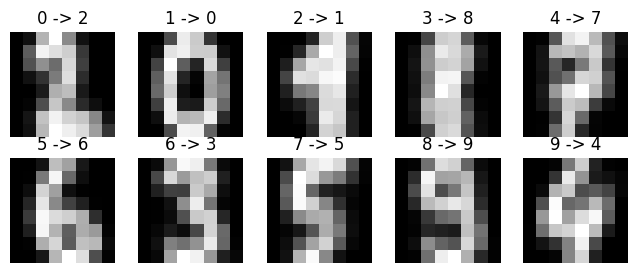

In [237]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 3))

labels_map = {0: 2, 1: 0, 2: 1, 3: 8, 4: 7, 5: 6, 6: 3, 7: 5, 8: 9, 9: 4}

for i in range(0, 10):
    ax = fig.add_subplot(2, 5, i + 1)
    ax.imshow(model.cluster_centers_[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'{i} -> {labels_map[i]}')
    ax.axis('off')

mapped_labels = [labels_map[i] for i in model.labels_]


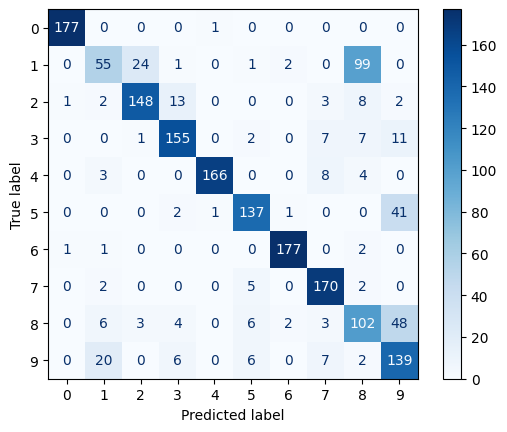

[[177   0   0   0   1   0   0   0   0   0]
 [  0  55  24   1   0   1   2   0  99   0]
 [  1   2 148  13   0   0   0   3   8   2]
 [  0   0   1 155   0   2   0   7   7  11]
 [  0   3   0   0 166   0   0   8   4   0]
 [  0   0   0   2   1 137   1   0   0  41]
 [  1   1   0   0   0   0 177   0   2   0]
 [  0   2   0   0   0   5   0 170   2   0]
 [  0   6   3   4   0   6   2   3 102  48]
 [  0  20   0   6   0   6   0   7   2 139]]


In [238]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(digits.data)
y_pred_mapped = [labels_map[i] for i in y_pred]
cm = confusion_matrix(digits.target, y_pred_mapped)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap='Blues')
plt.show()
plt.close()

print(cm)

In [239]:
from sklearn.metrics import silhouette_score, f1_score, adjusted_rand_score, normalized_mutual_info_score

sil = silhouette_score(digits.data, model.labels_)
f1_macro = f1_score(digits.target, y_pred_mapped, average='macro')
f1_weighted = f1_score(digits.target, y_pred_mapped, average='weighted')
ari = adjusted_rand_score(digits.target, model.labels_)
nmi = normalized_mutual_info_score(digits.target, model.labels_)

print('Test senza PCA')
print('silhouette_score:', sil)
print('f1_macro:', f1_macro)
print('f1_weighted:', f1_weighted)
print('ari:', ari)
print('nmi:', nmi)

Test senza PCA
silhouette_score: 0.18238453546718567
f1_macro: 0.7894620863890832
f1_weighted: 0.7899170245294868
ari: 0.6669121092859385
nmi: 0.7394281312140343


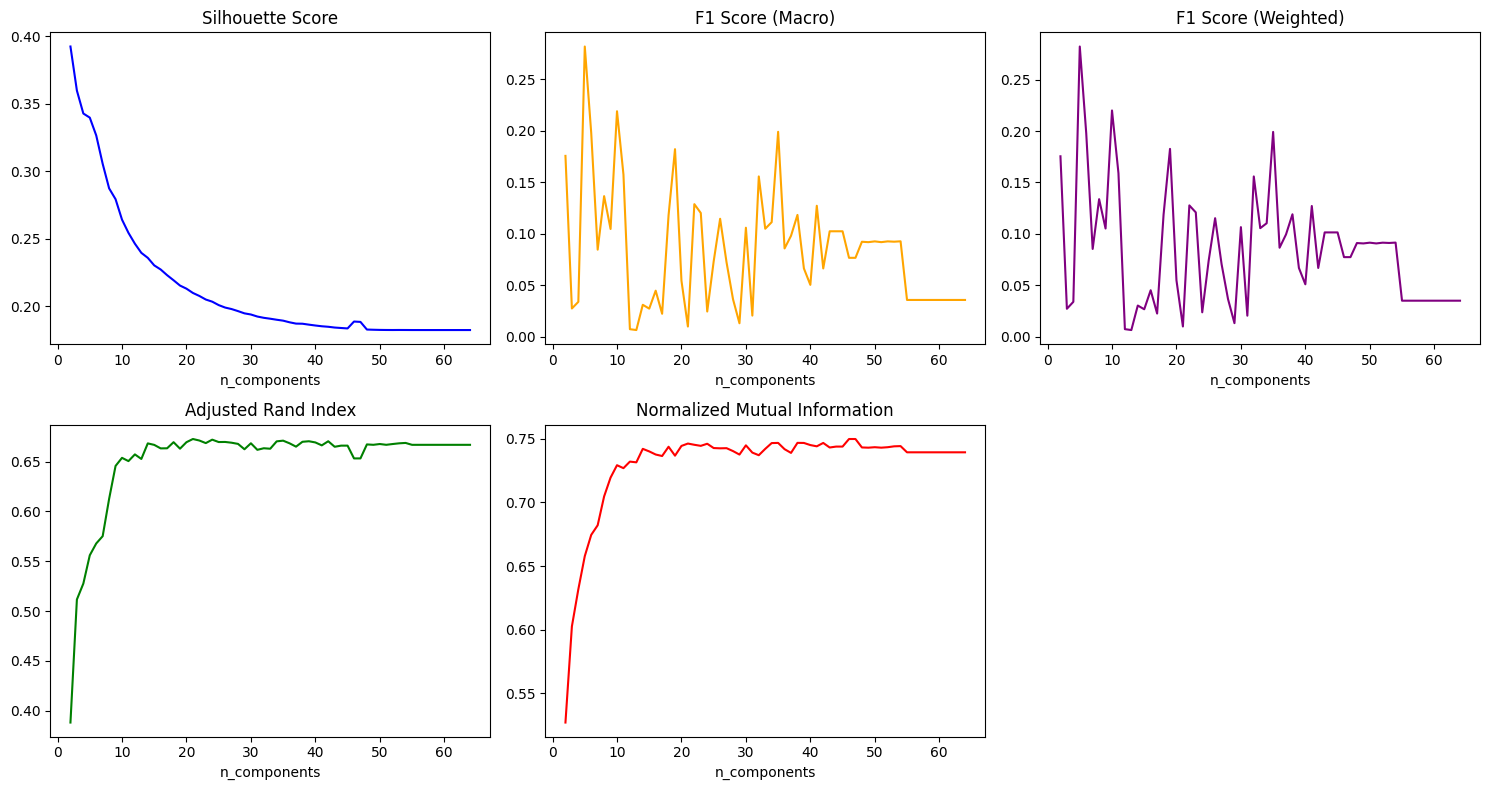

In [240]:
from sklearn.decomposition import PCA
import pandas as pd

scores = []
for i in range(2, 65):
    pca = PCA(n_components=i, random_state=42)
    data_pca = pca.fit_transform(digits.data)

    model_pca = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)
    model_pca.fit(data_pca)

    sil = silhouette_score(data_pca, model_pca.labels_)
    f1_macro = f1_score(digits.target, model_pca.labels_, average='macro')
    f1_weighted = f1_score(digits.target, model_pca.labels_, average='weighted')
    ari = adjusted_rand_score(digits.target, model_pca.labels_)
    nmi = normalized_mutual_info_score(digits.target, model_pca.labels_)
    scores.append({'i': i, 'sil': sil, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted, 'ari': ari, 'nmi': nmi})


scores = pd.DataFrame(scores, index=[s['i'] for s in scores]).reset_index(drop=True)

fig = plt.figure(figsize=(15, 8))

metrics = [
    (scores['sil'],       'Silhouette Score',              'blue'),
    (scores['f1_macro'],  'F1 Score (Macro)',               'orange'),
    (scores['f1_weighted'],'F1 Score (Weighted)',           'purple'),
    (scores['ari'],       'Adjusted Rand Index',            'green'),
    (scores['nmi'],       'Normalized Mutual Information',  'red'),
]

for i, (data, title, color) in enumerate(metrics):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.plot(range(2, 65), data, color=color)
    ax.set_title(title)
    ax.set_xlabel('n_components')

plt.tight_layout()
plt.show()


In [241]:
print("Miglior n per ARI:  ", scores['ari'].idxmax() + 2)
print("Miglior n per NMI:  ", scores['nmi'].idxmax() + 2)
print("Miglior n per F1 Macro:   ", scores['f1_macro'].idxmax() + 2)
print("Miglior n per F1 Weighted:", scores['f1_weighted'].idxmax() + 2)


Miglior n per ARI:   21
Miglior n per NMI:   46
Miglior n per F1 Macro:    5
Miglior n per F1 Weighted: 5


In [242]:
best_pca = PCA(n_components=21, random_state=42)
#Oppure n_components=0.95 direttamente, il risultato peggiora
data_pca = best_pca.fit_transform(digits.data)

print('Total variance explained by PCA: ', sum(best_pca.explained_variance_ratio_))

best_model = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)
best_model.fit(data_pca)

Total variance explained by PCA:  0.9031985012037212


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


<Figure size 800x300 with 0 Axes>

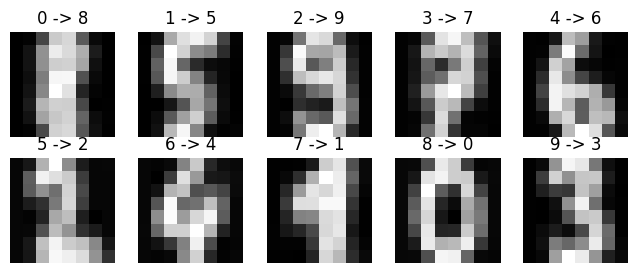

In [243]:
fig = plt.figure(figsize=(8, 3))

labels_map = {0: 8, 1: 5, 2: 9, 3: 7, 4: 6, 5: 2, 6: 4, 7: 1, 8: 0, 9: 3}
#labels_map = {0: 1, 1: 5, 2: 6, 3: 8, 4: 7, 5: 2, 6: 0, 7: 9, 8: 4, 9: 3} con 0.95 varianza spiegata

centers_original = best_pca.inverse_transform(best_model.cluster_centers_)

fig = plt.figure(figsize=(8, 3))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1)
    ax.imshow(centers_original[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'{i} -> {labels_map[i]}')
    ax.axis('off')


In [244]:
y_pred = best_model.predict(data_pca)
y_pred_mapped = [labels_map[i] for i in y_pred]

sil = silhouette_score(data_pca, best_model.labels_)
f1_macro = f1_score(digits.target, y_pred_mapped, average='macro')
f1_weighted = f1_score(digits.target, y_pred_mapped, average='weighted')
ari = adjusted_rand_score(digits.target, best_model.labels_)
nmi = normalized_mutual_info_score(digits.target, best_model.labels_)

print('Test w 21 components')
print('silhouette_score:', sil)
print('f1_macro:', f1_macro)
print('f1_weighted:', f1_weighted)
print('ari:', ari)
print('nmi:', nmi)

Test w 21 components
silhouette_score: 0.20986654646467795
f1_macro: 0.7924965575414789
f1_weighted: 0.7929704364358607
ari: 0.6727510466209679
nmi: 0.746306534806364


### Silhouette Score [-1, 1]
Misura quanto un campione è simile al proprio cluster rispetto agli altri.
Più alto = cluster compatti e separati. Bias geometrico in spazi ad alta dimensionalità.

### F1 Score (Macro/Weighted) [0, 1]
*Macro*: media semplice dell'F1 per ogni classe — penalizza le classi difficili equamente.
*Weighted*: media pesata per frequenza — classi più numerose influenzano di più.
Richiede labels_map corretta per essere affidabile nel clustering.

### Adjusted Rand Index - ARI [-1, 1]
Conta le coppie di campioni correttamente raggruppate/separate, corretto per il caso.
0 = casuale, 1 = perfetto. Non richiede labels_map.

Le due condizioni per avere ACCORDO su una coppia (A, B):

**CASO 1** — Stessa classe reale + Stesso cluster predetto ✅✅
"Questi due dovevano stare insieme, e KMeans li ha messi insieme" → ACCORDO

**CASO 2** — Classi diverse + Cluster diversi ✅✅
"Questi due dovevano stare separati, e KMeans li ha separati" → ACCORDO

*DISACCORDO*:
Stessa classe reale + Cluster diversi ✅❌
"Dovevano stare insieme, ma KMeans li ha separati" → DISACCORDO

Classi diverse + Stesso cluster ❌✅
"Dovevano stare separati, ma KMeans li ha uniti" → DISACCORDO


### Normalized Mutual Information - NMI [0, 1]
Misura quanta informazione condividono i cluster predetti e le label reali.
0 = nessuna correlazione, 1 = corrispondenza perfetta. Non richiede labels_map.


**In questo caso non è molto utile il PCA, spicca soprattutto in dataset con feature ridondanti, molte feature, rumore significativo** 